MULTI ARM bandit, problem -

Epsilon Greedy algorithm

--- Starting Multi-Armed Bandit Simulation (Epsilon-Greedy) ---
Total Impressions (Trials): 1000
Exploration Rate (Epsilon): 10.0%
-------------------------------------------------------
True CTRs (Hidden Performance):
  Top Banner (Arm 0): 5.00%
  Sidebar (Arm 1): 2.00%
  Footer (Arm 2): 1.00%
  Pop-up (Arm 3): 10.00%
-------------------------------------------------------
Impression 200/1000: Current Clicks = 26. Best Estimated Slot: Pop-up (Arm 3)
Impression 400/1000: Current Clicks = 42. Best Estimated Slot: Pop-up (Arm 3)
Impression 600/1000: Current Clicks = 62. Best Estimated Slot: Pop-up (Arm 3)
Impression 800/1000: Current Clicks = 83. Best Estimated Slot: Pop-up (Arm 3)
Impression 1000/1000: Current Clicks = 106. Best Estimated Slot: Pop-up (Arm 3)

--- Simulation Complete ---
Total Clicks Achieved (Cumulative Reward): 106
Overall CTR: 10.60%

Final Results after 1000 Impressions:
AD SLOT              | PLAYS    | CLICKS     | ESTIMATED CTR   | TRUE CTR       
---------------

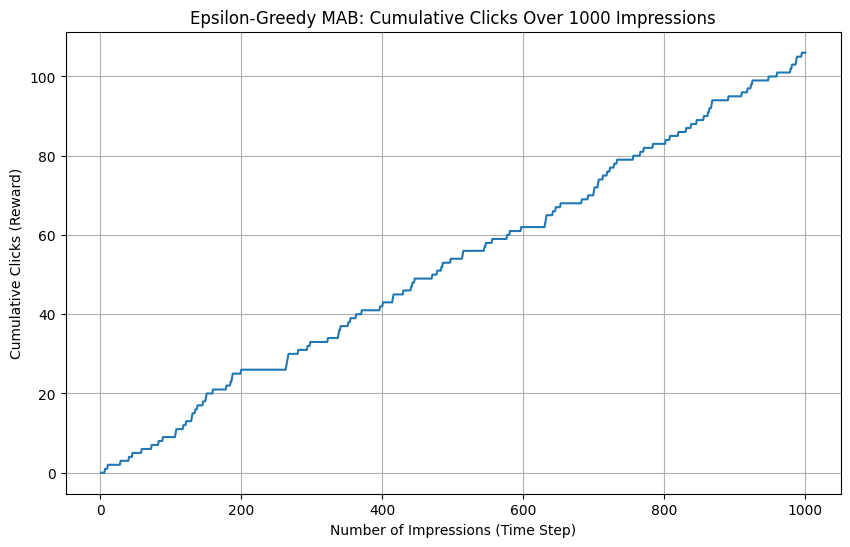

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# --- 1. Define the Problem Environment (The 'True' state, unknown to the algorithm) ---
# We define the true Click-Through Rates (CTRs) for the four ad slots.
# The algorithm's goal is to find the best one (Pop-up: 0.10) without knowing these in advance.
AD_SLOTS = ['Top Banner (Arm 0)', 'Sidebar (Arm 1)', 'Footer (Arm 2)', 'Pop-up (Arm 3)']
TRUE_CTRS = [0.05, 0.02, 0.01, 0.10]
NUM_ARMS = len(AD_SLOTS)

# --- 2. Simulation Parameters ---
EPSILON = 0.1  # 10% chance of exploration (random slot selection)
NUM_IMPRESSIONS = 1000 # Total number of trials (ad displays)

# --- 3. Initialization ---
# Counters for the Epsilon-Greedy Algorithm
counts = np.zeros(NUM_ARMS)      # N(a): number of times arm 'a' has been played
total_rewards = np.zeros(NUM_ARMS) # R(a): total reward (clicks) received from arm 'a'
estimated_ctrs = np.zeros(NUM_ARMS)  # Q(a): estimated value (average CTR) for arm 'a'

# Track simulation results
history = []

def select_arm():
    """
    Selects an ad slot (arm) based on the Epsilon-Greedy strategy.
    """
    # Exploration (Epsilon chance)
    if random.random() < EPSILON:
        # Choose a random arm
        arm_index = random.randint(0, NUM_ARMS - 1)
        # print(f"Exploration: Selecting random arm {arm_index}") # Debugging line
    # Exploitation (1 - Epsilon chance)
    else:
        # Choose the arm with the current highest estimated CTR (Exploitation)
        # Handle initial state: if all estimated_ctrs are 0, it selects the first one (index 0).
        arm_index = np.argmax(estimated_ctrs)
        # print(f"Exploitation: Selecting best arm {arm_index} with CTR {estimated_ctrs[arm_index]:.4f}") # Debugging line

    return arm_index

def get_reward(arm_index):
    """
    Simulates showing an ad and getting a binary reward (click=1, no click=0).
    """
    # The reward is based on the TRUE, hidden CTR of that specific ad slot.
    if random.random() < TRUE_CTRS[arm_index]:
        return 1  # Click
    else:
        return 0  # No click

def update_arm(arm_index, reward):
    """
    Updates the statistics for the chosen ad slot (arm).
    """
    # 1. Increment the count for the chosen arm
    counts[arm_index] += 1

    # 2. Add the reward to the total reward
    total_rewards[arm_index] += reward

    # 3. Calculate the new estimated CTR (Average Reward)
    # New Q(a) = Total Rewards / Total Plays
    estimated_ctrs[arm_index] = total_rewards[arm_index] / counts[arm_index]

# --- 4. Run the Simulation ---
print("--- Starting Multi-Armed Bandit Simulation (Epsilon-Greedy) ---")
print(f"Total Impressions (Trials): {NUM_IMPRESSIONS}")
print(f"Exploration Rate (Epsilon): {EPSILON * 100}%")
print("-" * 55)
print("True CTRs (Hidden Performance):")
for i, (name, ctr) in enumerate(zip(AD_SLOTS, TRUE_CTRS)):
    print(f"  {name}: {ctr * 100:.2f}%")
print("-" * 55)

cumulative_reward = 0
for t in range(1, NUM_IMPRESSIONS + 1):
    # Step 1: Select the next ad slot (arm)
    chosen_arm_index = select_arm()

    # Step 2: Observe the reward (click or no click)
    reward = get_reward(chosen_arm_index)

    # Step 3: Update the arm's statistics
    update_arm(chosen_arm_index, reward)

    # Track performance
    cumulative_reward += reward
    history.append(cumulative_reward)

    # Optional: print occasional updates
    if t % 200 == 0:
        print(f"Impression {t}/{NUM_IMPRESSIONS}: Current Clicks = {cumulative_reward}. Best Estimated Slot: {AD_SLOTS[np.argmax(estimated_ctrs)]}")


# --- 5. Display Final Results ---
print("\n--- Simulation Complete ---")
print(f"Total Clicks Achieved (Cumulative Reward): {cumulative_reward}")
print(f"Overall CTR: {cumulative_reward / NUM_IMPRESSIONS * 100:.2f}%")
print("\nFinal Results after 1000 Impressions:")
print("{:<20} | {:<8} | {:<10} | {:<15} | {:<15}".format(
    "AD SLOT", "PLAYS", "CLICKS", "ESTIMATED CTR", "TRUE CTR"))
print("-" * 80)

for i in range(NUM_ARMS):
    plays = int(counts[i])
    clicks = int(total_rewards[i])
    est_ctr = estimated_ctrs[i] if plays > 0 else 0

    print("{:<20} | {:<8} | {:<10} | {:<15.4f} | {:<15.4f}".format(
        AD_SLOTS[i], plays, clicks, est_ctr, TRUE_CTRS[i]))

print("-" * 80)
print(f"The algorithm correctly identified the best slot as: {AD_SLOTS[np.argmax(estimated_ctrs)]}")

# --- 6. Plotting the Cumulative Reward ---
plt.figure(figsize=(10, 6))
plt.plot(range(1, NUM_IMPRESSIONS + 1), history)
plt.title(f'Epsilon-Greedy MAB: Cumulative Clicks Over {NUM_IMPRESSIONS} Impressions')
plt.xlabel('Number of Impressions (Time Step)')
plt.ylabel('Cumulative Clicks (Reward)')
plt.grid(True)
plt.show()